# Figure 1

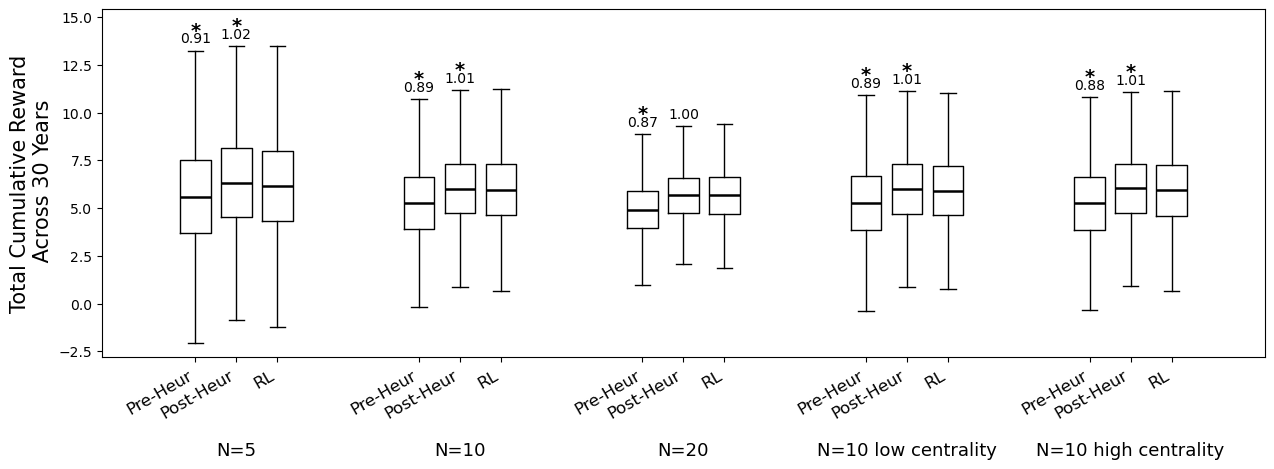

In [1]:
# compare RL, heuristic 1, and heuristic 2 performance
from call_in_data import *
from avgperformance import *
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import scipy.stats as stats
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

##########################################
heur_type = 4 # pre-RL observation heuristics
##########################################



# get RL performance for n=18,20,21,22,23
n21filename = './human_play_results/RL_performance_summary_seed252358_n21.csv'
n20filename = './human_play_results/RL_performance_summary_seed398845_n20.csv'
n18filename = './human_play_results/RL_performance_summary_seed578396_n18.csv'
n22filename = './human_play_results/RL_performance_summary_seed839394_n22.csv'
n23filename = './human_play_results/RL_performance_summary_seed444253_n23.csv'

# read in the csv files
summaryn18 = pd.read_csv(n18filename).iloc[1:]
summaryn20 = pd.read_csv(n20filename).iloc[1:]
summaryn21 = pd.read_csv(n21filename).iloc[1:]
summaryn22 = pd.read_csv(n22filename).iloc[1:]
summaryn23 = pd.read_csv(n23filename).iloc[1:]

rl_summary = {
    18: summaryn18['rewards'].astype(float),
    20: summaryn20['rewards'].astype(float),
    21: summaryn21['rewards'].astype(float),
    22: summaryn22['rewards'].astype(float),
    23: summaryn23['rewards'].astype(float),
}

group_name = {
    18: 'N=5',
    20: 'N=10',
    21: 'N=20',
    22: 'N=10 low centrality',
    23: 'N=10 high centrality',
}

envids = [18, 20, 21, 22, 23]
group_labels = [group_name[n] for n in envids]

def read_heur_series(heur_id, n):
    candidates = [
        f'./heuristics_play_results/heur{heur_id}_performance_summary_n{n}.csv',
        f'./performance_summary/heur{heur_id}_performance_summary_n{n}.csv',
    ]
    for fname in candidates:
        if os.path.exists(fname):
            return pd.read_csv(fname).iloc[1:]['rewards'].astype(float)

    #if heur_id == 2:
    #    fallback = f'./heuristics_play_results/heur5_performance_summary_n{n}.csv'
    #    if os.path.exists(fallback):
    #        print(f'heur2 file missing for n={n}; using heur5 file instead.')
    #        return pd.read_csv(fallback).iloc[1:]['rewards'].astype(float)

    raise FileNotFoundError(f'No summary file found for heur{heur_id}, n={n}')

heur1_summary = {n: read_heur_series(heur_type, n) for n in envids} # pre-RL observation heuristics
heur2_summary = {n: read_heur_series(5, n) for n in envids} # post-RL observation heuristics

box_width = 0.22
group_spacing = 1.20
positions_per_group = np.array([0, 1, 2]) * box_width  # Pre-Heur, Post-Heur, RL
group_centers = np.arange(len(envids)) * group_spacing

fig, ax = plt.subplots(figsize=(15, 6))

all_positions = []
all_type_labels = []
max_annotation_y = -np.inf

for i, n in enumerate(envids):
    # Order within each group: Pre-Heur, Post-Heur, RL
    data = [
        heur1_summary[n].values,
        heur2_summary[n].values,
        rl_summary[n].values,
    ]

    pos = group_centers[i] + positions_per_group - box_width
    bp = ax.boxplot(
        data,
        positions=pos,
        widths=box_width * 0.75,
        showfliers=False,
        showmeans=True,
        meanline=True,
        meanprops=dict(color='black', linewidth=1.8, linestyle='-'),
        medianprops=dict(color='none', linewidth=0),
    )

    # Annotate ratios above top whiskers for Pre/Post: mean(heur) / mean(RL).
    # Add a significance star above the ratio for Welch's t-test vs RL (p < 0.05).
    rl_mean = np.mean(data[2])
    for j in [0, 1]:
        test_res = stats.ttest_ind(data[j], data[2], equal_var=False, nan_policy='omit')
        p_val = float(test_res.pvalue) if np.isfinite(test_res.pvalue) else np.nan

        if rl_mean != 0:
            ratio = np.mean(data[j]) / rl_mean
            w_low = bp['whiskers'][2 * j].get_ydata()
            w_high = bp['whiskers'][2 * j + 1].get_ydata()
            y_top = max(np.max(w_low), np.max(w_high))

            ratio_y = y_top + 0.25
            ax.text(pos[j], ratio_y, f'{ratio:.2f}', ha='center', va='bottom', fontsize=10)
            max_annotation_y = max(max_annotation_y, ratio_y)

            if np.isfinite(p_val) and p_val < 0.05:
                star_y = y_top + 0.55
                ax.text(pos[j], star_y, '*', ha='center', va='bottom', fontsize=14, fontweight='bold')
                max_annotation_y = max(max_annotation_y, star_y)

    all_positions.extend(pos.tolist())
    all_type_labels.extend(['Pre-Heur', 'Post-Heur', 'RL'])

# X-axis: Pre-Heur/Post-Heur/RL repeated within each group.
ax.set_xticks(all_positions)
ax.set_xticklabels(all_type_labels, fontsize=12, rotation=30, ha='right')

# Add environment group labels under each triplet with extra vertical spacing.
for center, label in zip(group_centers, group_labels):
    ax.text(center, -0.24, label, ha='center', va='top', transform=ax.get_xaxis_transform(), fontsize=13)

ax.set_ylabel('Total Cumulative Reward\n Across 30 Years', fontsize=15)

# Expand top y-limit with extra headroom so top annotations are not crowded.
if np.isfinite(max_annotation_y):
    y_min, y_max = ax.get_ylim()
    y_range = y_max - y_min
    top_pad = max(0.8, 0.08 * y_range)
    desired_top = max_annotation_y + top_pad
    if desired_top > y_max:
        ax.set_ylim(y_min, desired_top)

# Increase bottom margin to avoid overlap between tick labels and group labels.
plt.subplots_adjust(bottom=0.30)
plt.show()

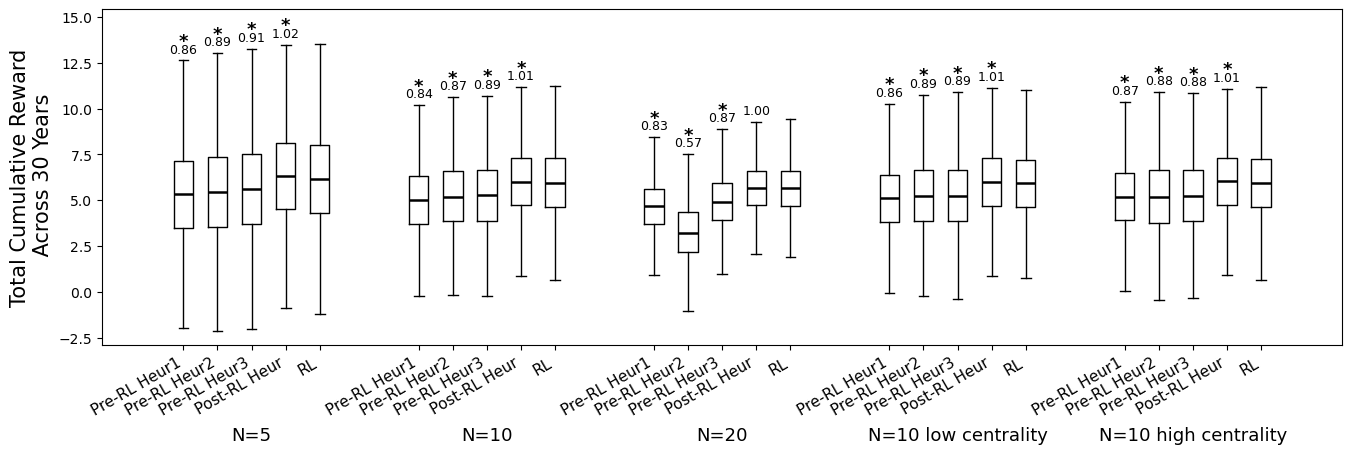

In [7]:
# Figure 1 variant: compare Heur1, Heur2, Heur3, Post-RL Heur, and RL performance
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Uses objects defined in Cell 2: envids, group_name, rl_summary, read_heur_series
heur1_summary = {n: read_heur_series(1, n) for n in envids}
heur2_summary = {n: read_heur_series(3, n) for n in envids}
heur3_summary = {n: read_heur_series(4, n) for n in envids}
postrl_summary = {n: read_heur_series(5, n) for n in envids}

group_labels = [group_name[n] for n in envids]

box_width = 0.16
intra_group_step = 0.21  # Increase horizontal spacing between boxes within each group.
group_spacing = 1.45
positions_per_group = np.arange(5) * intra_group_step  # Heur1, Heur2, Heur3, Post-RL Heur, RL
group_centers = np.arange(len(envids)) * group_spacing

fig, ax = plt.subplots(figsize=(16, 6))

all_positions = []
all_type_labels = []
max_annotation_y = -np.inf

for i, n in enumerate(envids):
    # Order within each group: Heur1, Heur2, Heur3, Post-RL Heur, RL
    data = [
        heur1_summary[n].values,
        heur2_summary[n].values,
        heur3_summary[n].values,
        postrl_summary[n].values,
        rl_summary[n].values,
    ]

    pos = group_centers[i] + positions_per_group - (2 * intra_group_step)
    bp = ax.boxplot(
        data,
        positions=pos,
        widths=box_width * 0.75,
        showfliers=False,
        showmeans=True,
        meanline=True,
        meanprops=dict(color='black', linewidth=1.8, linestyle='-'),
        medianprops=dict(color='none', linewidth=0),
    )

    # Annotate ratios above top whiskers for each heuristic: mean(heur) / mean(RL).
    # Add a significance star above the ratio for Welch's t-test vs RL (p < 0.05).
    rl_mean = np.mean(data[4])
    for j in [0, 1, 2, 3]:
        test_res = stats.ttest_ind(data[j], data[4], equal_var=False, nan_policy='omit')
        p_val = float(test_res.pvalue) if np.isfinite(test_res.pvalue) else np.nan

        if rl_mean != 0:
            ratio = np.mean(data[j]) / rl_mean
            w_low = bp['whiskers'][2 * j].get_ydata()
            w_high = bp['whiskers'][2 * j + 1].get_ydata()
            y_top = max(np.max(w_low), np.max(w_high))

            ratio_y = y_top + 0.25
            ax.text(pos[j], ratio_y, f'{ratio:.2f}', ha='center', va='bottom', fontsize=9)
            max_annotation_y = max(max_annotation_y, ratio_y)

            if np.isfinite(p_val) and p_val < 0.05:
                star_y = y_top + 0.55
                ax.text(pos[j], star_y, '*', ha='center', va='bottom', fontsize=13, fontweight='bold')
                max_annotation_y = max(max_annotation_y, star_y)

    all_positions.extend(pos.tolist())
    all_type_labels.extend(['Pre-RL Heur1', 'Pre-RL Heur2', 'Pre-RL Heur3', 'Post-RL Heur', 'RL'])

# X-axis: method labels repeated within each environment group.
ax.set_xticks(all_positions)
ax.set_xticklabels(all_type_labels, fontsize=11, rotation=30, ha='right')

# Add environment group labels under each quintet with extra vertical spacing.
for center, label in zip(group_centers, group_labels):
    ax.text(center, -0.24, label, ha='center', va='top', transform=ax.get_xaxis_transform(), fontsize=13)

ax.set_ylabel('Total Cumulative Reward\n Across 30 Years', fontsize=15)

# Expand top y-limit with extra headroom so top annotations are not crowded.
if np.isfinite(max_annotation_y):
    y_min, y_max = ax.get_ylim()
    y_range = y_max - y_min
    top_pad = max(0.8, 0.08 * y_range)
    desired_top = max_annotation_y + top_pad
    if desired_top > y_max:
        ax.set_ylim(y_min, desired_top)

# Increase bottom margin to avoid overlap between tick labels and group labels.
plt.subplots_adjust(bottom=0.32)
plt.show()

# Figure 2

20


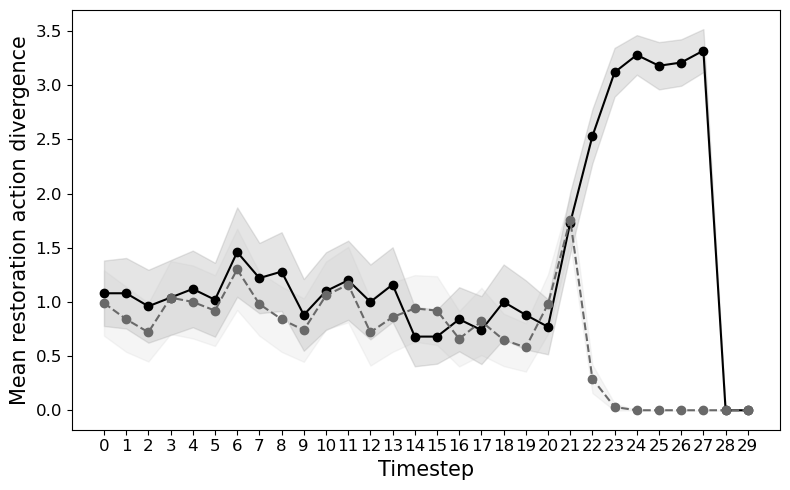

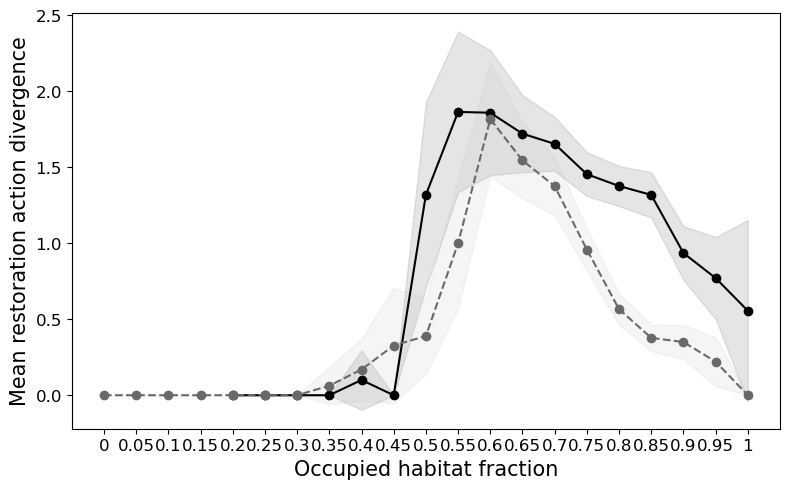

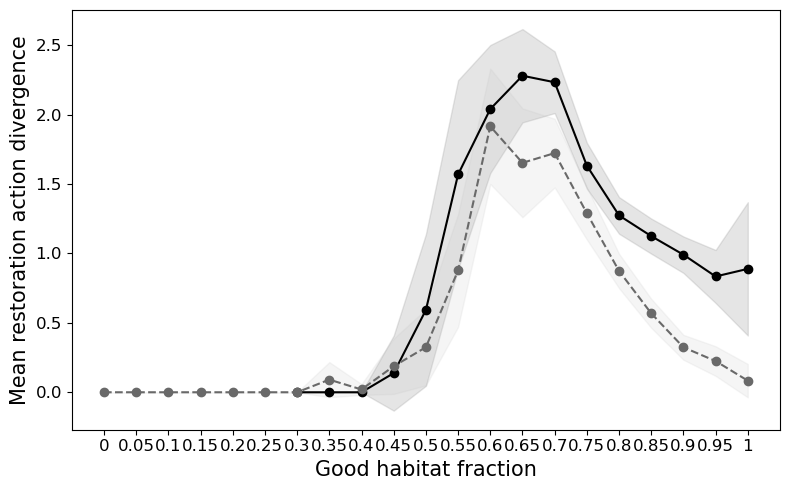

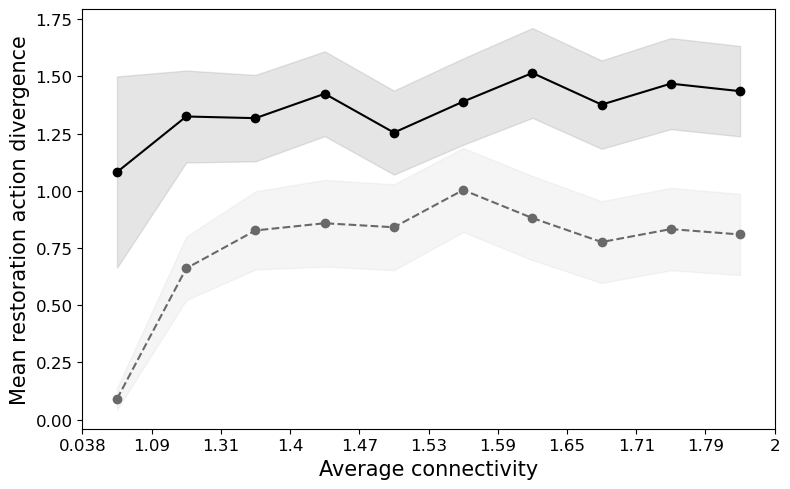

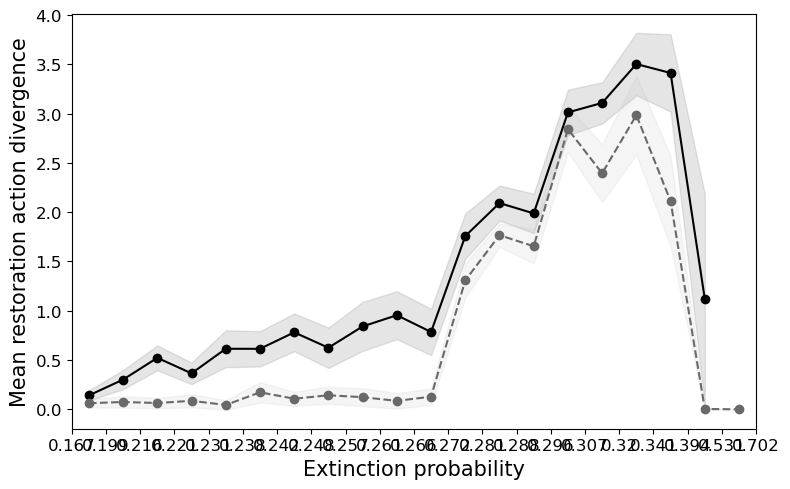

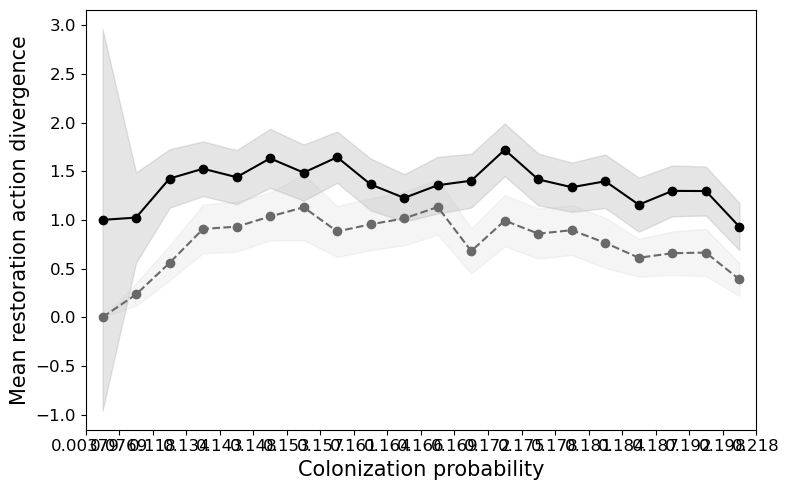

In [4]:
# restoration action distance analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from call_in_data import call_in_data, call_in_heuristic_data

###################################################
envid = 21 # 18= n5, 20=n10 median centrality, 21=n20, 22=n10 low centrality, 23=n10 high centrality
legend_on =0  # if 1, show legend/title; if 0, hide both.
heurtype = 4
# only use 20. we specifically got more samples for step-scale analysis.
###################################################

# Heuristic play data (type 1 and type 5)
heur1_playdf, _ = call_in_heuristic_data(envid=envid, heuristic_type=heurtype, with_valdiff=True, merge=True) # pre-RL observation heuristics
heur5_playdf, _ = call_in_heuristic_data(envid=envid, heuristic_type=5, with_valdiff=False, merge=True)
patchnum = heur1_playdf['observations'][0].shape[0]  # assuming all observations have the same shape
print(patchnum)

# Human play data
human_playdf, _ = call_in_data(envid=envid, with_valdiff=True, merge=True)

def build_df(playdf, patchnum):
    #delV, V_human, V_pi = zip(*playdf['performance_gap'])
    t = np.array([s[0, -1] for s in playdf['observations']])
    occfrac = playdf['occfraction_per_episode']
    goodhfrac = playdf['goodHfraction_per_episode']
    avgconn = playdf['avgconnectivity_per_episode']
    eprob = playdf['avgeprob_per_episode']
    cprob = playdf['avgcprob_per_episode']

    # Restoration action distance relative to RL action (first half of action vector).
    radist = (np.abs(np.array(playdf['actions']) - np.array(playdf['RLactions']))[:, :patchnum]).sum(axis=1)

    return pd.DataFrame({
        #'delV': delV,
        't': t,
        'occfrac': occfrac,
        'goodhfrac': goodhfrac,
        'avgconn': avgconn,
        'eprob': eprob,
        'cprob': cprob,
        'radist': radist,
    })

heur1_df = build_df(heur1_playdf, patchnum)
heur5_df = build_df(heur5_playdf, patchnum)
human_df = build_df(human_playdf, patchnum)

# Plot mean restoration distance against each state variable in separate figures.
plot_specs = [
    ('t', 20, 'Timestep', 'Restoration action distance vs\n Timestep'),
    ('occfrac', 3, 'Occupied habitat fraction', 'Restoration action distance vs\n Occupied Habitat Fraction'),
    ('goodhfrac', 3, 'Good habitat fraction', 'Restoration action distance vs\n Good Habitat Fraction'),
    ('avgconn', 10, 'Average connectivity', 'Restoration action distance vs\n Average Connectivity'),
    ('eprob', 20, 'Extinction probability', 'Restoration action distance vs\n Extinction Probability'),
    ('cprob', 20, 'Colonization probability', 'Restoration action distance vs\n Colonization Probability'),
]

discrete_cols = {'t', 'occfrac', 'goodhfrac'}

heur1_line_color = 'black'
heur1_ci_color = 'gray'
heur1_line_style = '-'
heur5_line_color = 'dimgray'
heur5_ci_color = 'silver'
heur5_line_style = '--'
human_line_color = 'black'
human_ci_color = 'gray'
human_line_style = ':'

def fill_binned_arrays(grouped_df, n_actual_bins):
    means = np.full(n_actual_bins, np.nan, dtype=float)
    stds = np.full(n_actual_bins, np.nan, dtype=float)
    counts = np.zeros(n_actual_bins, dtype=float)
    for idx, row in grouped_df.iterrows():
        if pd.notna(idx):
            i = int(idx)
            means[i] = float(row['mean'])
            stds[i] = 0.0 if pd.isna(row['std']) else float(row['std'])
            counts[i] = float(row['count'])
    return means, stds, counts

for col, n_bins, xlabel, title in plot_specs:
    h1x = pd.to_numeric(heur1_df[col], errors='coerce')
    h1y = pd.to_numeric(heur1_df['radist'], errors='coerce')
    h1v = h1x.notna() & h1y.notna()
    h1x = h1x[h1v]
    h1y = h1y[h1v]

    h5x = pd.to_numeric(heur5_df[col], errors='coerce')
    h5y = pd.to_numeric(heur5_df['radist'], errors='coerce')
    h5v = h5x.notna() & h5y.notna()
    h5x = h5x[h5v]
    h5y = h5y[h5v]

    ux = pd.to_numeric(human_df[col], errors='coerce')
    uy = pd.to_numeric(human_df['radist'], errors='coerce')
    uv = ux.notna() & uy.notna()
    ux = ux[uv]
    uy = uy[uv]

    plt.figure(figsize=(8, 5))

    if col in discrete_cols:
        # Equal spacing by category index, shared between both heuristics and human.
        all_vals = np.sort(np.unique(np.concatenate([h1x.to_numpy(), h5x.to_numpy(), ux.to_numpy()])))
        x_pos = np.arange(len(all_vals), dtype=float)

        h1_grouped = h1y.groupby(h1x).agg(['mean', 'std', 'count']).reindex(all_vals)
        h5_grouped = h5y.groupby(h5x).agg(['mean', 'std', 'count']).reindex(all_vals)
        u_grouped = uy.groupby(ux).agg(['mean', 'std', 'count']).reindex(all_vals)

        h1_means = h1_grouped['mean'].to_numpy(dtype=float)
        h1_stds = h1_grouped['std'].fillna(0.0).to_numpy(dtype=float)
        h1_counts = h1_grouped['count'].fillna(0.0).to_numpy(dtype=float)
        h1_sem = np.divide(h1_stds, np.sqrt(h1_counts), out=np.full_like(h1_stds, np.nan), where=h1_counts > 0)
        h1_ci95 = 1.96 * h1_sem

        h5_means = h5_grouped['mean'].to_numpy(dtype=float)
        h5_stds = h5_grouped['std'].fillna(0.0).to_numpy(dtype=float)
        h5_counts = h5_grouped['count'].fillna(0.0).to_numpy(dtype=float)
        h5_sem = np.divide(h5_stds, np.sqrt(h5_counts), out=np.full_like(h5_stds, np.nan), where=h5_counts > 0)
        h5_ci95 = 1.96 * h5_sem

        u_means = u_grouped['mean'].to_numpy(dtype=float)
        u_stds = u_grouped['std'].fillna(0.0).to_numpy(dtype=float)
        u_counts = u_grouped['count'].fillna(0.0).to_numpy(dtype=float)
        u_sem = np.divide(u_stds, np.sqrt(u_counts), out=np.full_like(u_stds, np.nan), where=u_counts > 0)
        u_ci95 = 1.96 * u_sem

        plt.plot(x_pos, h1_means, marker='o', linestyle=heur1_line_style, color=heur1_line_color, label='Heuristic 1 mean')
        plt.fill_between(x_pos, h1_means - h1_ci95, h1_means + h1_ci95, color=heur1_ci_color, alpha=0.20, label='Heuristic 1 95% CI')
        plt.plot(x_pos, h5_means, marker='o', linestyle=heur5_line_style, color=heur5_line_color, label='Heuristic 5 mean')
        plt.fill_between(x_pos, h5_means - h5_ci95, h5_means + h5_ci95, color=heur5_ci_color, alpha=0.15, label='Heuristic 5 95% CI')
        #plt.plot(x_pos, u_means, marker='o', linestyle=human_line_style, color=human_line_color, label='Human mean')
        #plt.fill_between(x_pos, u_means - u_ci95, u_means + u_ci95, color=human_ci_color, alpha=0.10, label='Human 95% CI')

        plt.xticks(x_pos, [f'{v:g}' for v in all_vals], fontsize=12)
        plt.yticks(fontsize=12)
        plt.xlabel(f'{xlabel}', fontsize=15)
    else:
        # Equal spacing by bin index with shared quantile edges across all datasets.
        all_x = pd.concat([h1x, h5x, ux], ignore_index=True)
        _, bin_edges = pd.qcut(all_x, q=n_bins, retbins=True, duplicates='drop')
        n_actual_bins = len(bin_edges) - 1

        h1_ids = pd.cut(h1x, bins=bin_edges, include_lowest=True, labels=False)
        h5_ids = pd.cut(h5x, bins=bin_edges, include_lowest=True, labels=False)
        u_ids = pd.cut(ux, bins=bin_edges, include_lowest=True, labels=False)

        h1_grouped = h1y.groupby(h1_ids).agg(['mean', 'std', 'count'])
        h5_grouped = h5y.groupby(h5_ids).agg(['mean', 'std', 'count'])
        u_grouped = uy.groupby(u_ids).agg(['mean', 'std', 'count'])

        h1_means, h1_stds, h1_counts = fill_binned_arrays(h1_grouped, n_actual_bins)
        h5_means, h5_stds, h5_counts = fill_binned_arrays(h5_grouped, n_actual_bins)
        u_means, u_stds, u_counts = fill_binned_arrays(u_grouped, n_actual_bins)

        h1_sem = np.divide(h1_stds, np.sqrt(h1_counts), out=np.full_like(h1_stds, np.nan), where=h1_counts > 0)
        h1_ci95 = 1.96 * h1_sem
        h5_sem = np.divide(h5_stds, np.sqrt(h5_counts), out=np.full_like(h5_stds, np.nan), where=h5_counts > 0)
        h5_ci95 = 1.96 * h5_sem
        u_sem = np.divide(u_stds, np.sqrt(u_counts), out=np.full_like(u_stds, np.nan), where=u_counts > 0)
        u_ci95 = 1.96 * u_sem

        x_mean_pos = np.arange(n_actual_bins, dtype=float) + 0.5
        x_edge_pos = np.arange(n_actual_bins + 1, dtype=float)
        edge_labels = [f'{e:.3g}' for e in bin_edges]

        plt.plot(x_mean_pos, h1_means, marker='o', linestyle=heur1_line_style, color=heur1_line_color, label='Heuristic 1 mean')
        plt.fill_between(x_mean_pos, h1_means - h1_ci95, h1_means + h1_ci95, color=heur1_ci_color, alpha=0.20, label='Heuristic 1 95% CI')
        plt.plot(x_mean_pos, h5_means, marker='o', linestyle=heur5_line_style, color=heur5_line_color, label='Heuristic 5 mean')
        plt.fill_between(x_mean_pos, h5_means - h5_ci95, h5_means + h5_ci95, color=heur5_ci_color, alpha=0.15, label='Heuristic 5 95% CI')
        #plt.plot(x_mean_pos, u_means, marker='o', linestyle=human_line_style, color=human_line_color, label='Human mean')
        #plt.fill_between(x_mean_pos, u_means - u_ci95, u_means + u_ci95, color=human_ci_color, alpha=0.10, label='Human 95% CI')

        plt.xticks(x_edge_pos, edge_labels, fontsize=12)
        plt.yticks(fontsize=12)
        plt.xlim(0, n_actual_bins)
        plt.xlabel(f'{xlabel}', fontsize=15)

    plt.ylabel('Mean restoration action divergence', fontsize=15)
    if legend_on == 1:
        plt.title(title, fontsize=15)
        plt.legend()
    #plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


20


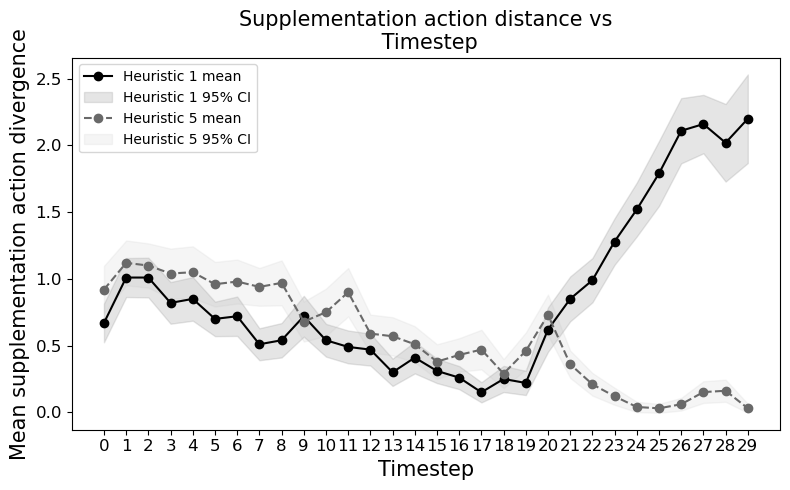

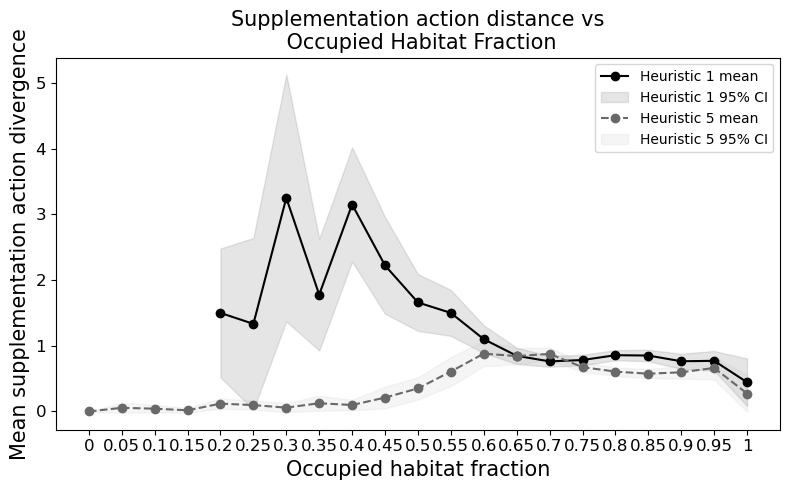

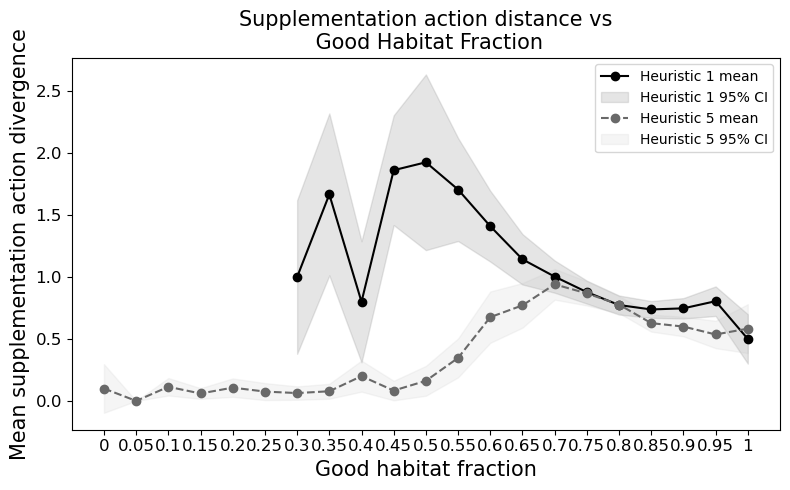

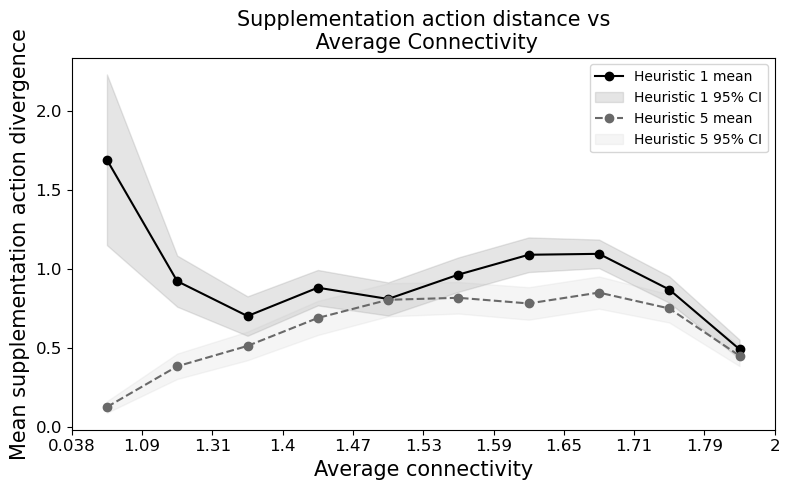

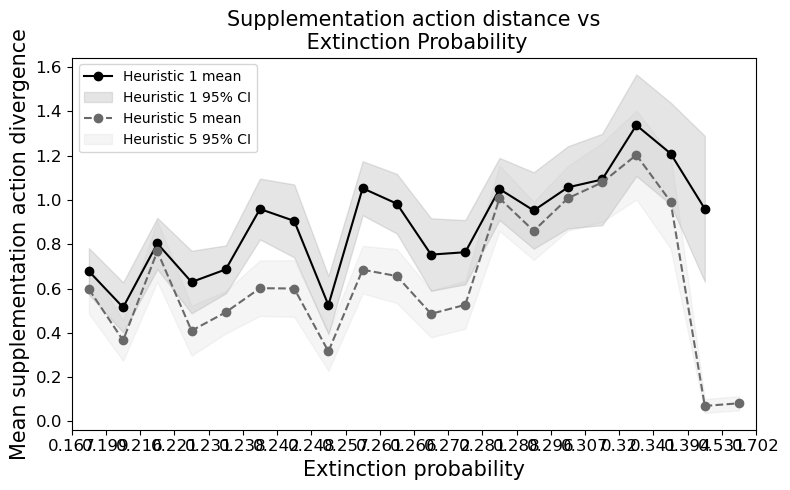

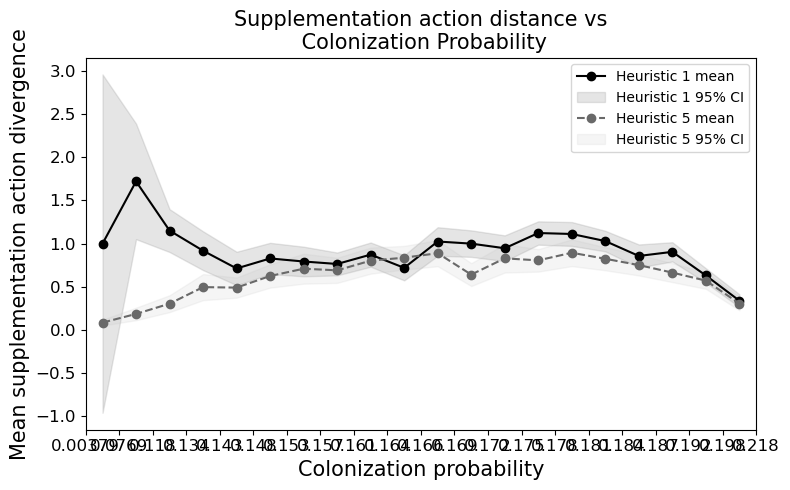

In [6]:
# supplementation action distance analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from call_in_data import call_in_data, call_in_heuristic_data

###################################################
envid = 20# 18=n5, 20=n10 median centrality, 21=n20, 22=n10 low centrality, 23=n10 high centrality
legend_on = 1 # if 1, show legend/title; if 0, hide both.
heurtype = 4 # pre-RL observation heuristics
# only use 20. we specifically got more samples for step-scale analysis.
###################################################

# Heuristic play data (type 1 and type 5)
heur1_playdf, _ = call_in_heuristic_data(envid=envid, heuristic_type=heurtype, with_valdiff=True, merge=True)
heur5_playdf, _ = call_in_heuristic_data(envid=envid, heuristic_type=5, with_valdiff=False, merge=True)
patchnum = heur1_playdf['observations'][0].shape[0]  # assuming all observations have the same shape
print(patchnum)

# Human play data
human_playdf, _ = call_in_data(envid=envid, with_valdiff=True, merge=True)

def build_df(playdf, patchnum):
    t = np.array([s[0, -1] for s in playdf['observations']])
    occfrac = playdf['occfraction_per_episode']
    goodhfrac = playdf['goodHfraction_per_episode']
    avgconn = playdf['avgconnectivity_per_episode']
    eprob = playdf['avgeprob_per_episode']
    cprob = playdf['avgcprob_per_episode']

    # Supplementation action distance relative to RL action (second half of action vector).
    sadist = (np.abs(np.array(playdf['actions']) - np.array(playdf['RLactions']))[:, patchnum:]).sum(axis=1)

    return pd.DataFrame({
        't': t,
        'occfrac': occfrac,
        'goodhfrac': goodhfrac,
        'avgconn': avgconn,
        'eprob': eprob,
        'cprob': cprob,
        'sadist': sadist,
    })

heur1_df = build_df(heur1_playdf, patchnum)
heur5_df = build_df(heur5_playdf, patchnum)
human_df = build_df(human_playdf, patchnum)

# Plot mean supplementation distance against each state variable in separate figures.
plot_specs = [
    ('t', 20, 'Timestep', 'Supplementation action distance vs\n Timestep'),
    ('occfrac', 3, 'Occupied habitat fraction', 'Supplementation action distance vs\n Occupied Habitat Fraction'),
    ('goodhfrac', 3, 'Good habitat fraction', 'Supplementation action distance vs\n Good Habitat Fraction'),
    ('avgconn', 10, 'Average connectivity', 'Supplementation action distance vs\n Average Connectivity'),
    ('eprob', 20, 'Extinction probability', 'Supplementation action distance vs\n Extinction Probability'),
    ('cprob', 20, 'Colonization probability', 'Supplementation action distance vs\n Colonization Probability'),
]

discrete_cols = {'t', 'occfrac', 'goodhfrac'}

heur1_line_color = 'black'
heur1_ci_color = 'gray'
heur1_line_style = '-'
heur5_line_color = 'dimgray'
heur5_ci_color = 'silver'
heur5_line_style = '--'
human_line_color = 'black'
human_ci_color = 'gray'
human_line_style = ':'

def fill_binned_arrays(grouped_df, n_actual_bins):
    means = np.full(n_actual_bins, np.nan, dtype=float)
    stds = np.full(n_actual_bins, np.nan, dtype=float)
    counts = np.zeros(n_actual_bins, dtype=float)
    for idx, row in grouped_df.iterrows():
        if pd.notna(idx):
            i = int(idx)
            means[i] = float(row['mean'])
            stds[i] = 0.0 if pd.isna(row['std']) else float(row['std'])
            counts[i] = float(row['count'])
    return means, stds, counts

for col, n_bins, xlabel, title in plot_specs:
    h1x = pd.to_numeric(heur1_df[col], errors='coerce')
    h1y = pd.to_numeric(heur1_df['sadist'], errors='coerce')
    h1v = h1x.notna() & h1y.notna()
    h1x = h1x[h1v]
    h1y = h1y[h1v]

    h5x = pd.to_numeric(heur5_df[col], errors='coerce')
    h5y = pd.to_numeric(heur5_df['sadist'], errors='coerce')
    h5v = h5x.notna() & h5y.notna()
    h5x = h5x[h5v]
    h5y = h5y[h5v]

    ux = pd.to_numeric(human_df[col], errors='coerce')
    uy = pd.to_numeric(human_df['sadist'], errors='coerce')
    uv = ux.notna() & uy.notna()
    ux = ux[uv]
    uy = uy[uv]

    plt.figure(figsize=(8, 5))

    if col in discrete_cols:
        # Equal spacing by category index, shared between both heuristics and human.
        all_vals = np.sort(np.unique(np.concatenate([h1x.to_numpy(), h5x.to_numpy(), ux.to_numpy()])))
        x_pos = np.arange(len(all_vals), dtype=float)

        h1_grouped = h1y.groupby(h1x).agg(['mean', 'std', 'count']).reindex(all_vals)
        h5_grouped = h5y.groupby(h5x).agg(['mean', 'std', 'count']).reindex(all_vals)
        u_grouped = uy.groupby(ux).agg(['mean', 'std', 'count']).reindex(all_vals)

        h1_means = h1_grouped['mean'].to_numpy(dtype=float)
        h1_stds = h1_grouped['std'].fillna(0.0).to_numpy(dtype=float)
        h1_counts = h1_grouped['count'].fillna(0.0).to_numpy(dtype=float)
        h1_sem = np.divide(h1_stds, np.sqrt(h1_counts), out=np.full_like(h1_stds, np.nan), where=h1_counts > 0)
        h1_ci95 = 1.96 * h1_sem

        h5_means = h5_grouped['mean'].to_numpy(dtype=float)
        h5_stds = h5_grouped['std'].fillna(0.0).to_numpy(dtype=float)
        h5_counts = h5_grouped['count'].fillna(0.0).to_numpy(dtype=float)
        h5_sem = np.divide(h5_stds, np.sqrt(h5_counts), out=np.full_like(h5_stds, np.nan), where=h5_counts > 0)
        h5_ci95 = 1.96 * h5_sem

        u_means = u_grouped['mean'].to_numpy(dtype=float)
        u_stds = u_grouped['std'].fillna(0.0).to_numpy(dtype=float)
        u_counts = u_grouped['count'].fillna(0.0).to_numpy(dtype=float)
        u_sem = np.divide(u_stds, np.sqrt(u_counts), out=np.full_like(u_stds, np.nan), where=u_counts > 0)
        u_ci95 = 1.96 * u_sem

        plt.plot(x_pos, h1_means, marker='o', linestyle=heur1_line_style, color=heur1_line_color, label='Heuristic 1 mean')
        plt.fill_between(x_pos, h1_means - h1_ci95, h1_means + h1_ci95, color=heur1_ci_color, alpha=0.20, label='Heuristic 1 95% CI')
        plt.plot(x_pos, h5_means, marker='o', linestyle=heur5_line_style, color=heur5_line_color, label='Heuristic 5 mean')
        plt.fill_between(x_pos, h5_means - h5_ci95, h5_means + h5_ci95, color=heur5_ci_color, alpha=0.15, label='Heuristic 5 95% CI')
        #plt.plot(x_pos, u_means, marker='o', linestyle=human_line_style, color=human_line_color, label='Human mean')
        #plt.fill_between(x_pos, u_means - u_ci95, u_means + u_ci95, color=human_ci_color, alpha=0.10, label='Human 95% CI')

        plt.xticks(x_pos, [f'{v:g}' for v in all_vals], fontsize=12)
        plt.yticks(fontsize=12)
        plt.xlabel(f'{xlabel}', fontsize=15)
    else:
        # Equal spacing by bin index with shared quantile edges across all datasets.
        all_x = pd.concat([h1x, h5x, ux], ignore_index=True)
        _, bin_edges = pd.qcut(all_x, q=n_bins, retbins=True, duplicates='drop')
        n_actual_bins = len(bin_edges) - 1

        h1_ids = pd.cut(h1x, bins=bin_edges, include_lowest=True, labels=False)
        h5_ids = pd.cut(h5x, bins=bin_edges, include_lowest=True, labels=False)
        u_ids = pd.cut(ux, bins=bin_edges, include_lowest=True, labels=False)

        h1_grouped = h1y.groupby(h1_ids).agg(['mean', 'std', 'count'])
        h5_grouped = h5y.groupby(h5_ids).agg(['mean', 'std', 'count'])
        u_grouped = uy.groupby(u_ids).agg(['mean', 'std', 'count'])

        h1_means, h1_stds, h1_counts = fill_binned_arrays(h1_grouped, n_actual_bins)
        h5_means, h5_stds, h5_counts = fill_binned_arrays(h5_grouped, n_actual_bins)
        u_means, u_stds, u_counts = fill_binned_arrays(u_grouped, n_actual_bins)

        h1_sem = np.divide(h1_stds, np.sqrt(h1_counts), out=np.full_like(h1_stds, np.nan), where=h1_counts > 0)
        h1_ci95 = 1.96 * h1_sem
        h5_sem = np.divide(h5_stds, np.sqrt(h5_counts), out=np.full_like(h5_stds, np.nan), where=h5_counts > 0)
        h5_ci95 = 1.96 * h5_sem
        u_sem = np.divide(u_stds, np.sqrt(u_counts), out=np.full_like(u_stds, np.nan), where=u_counts > 0)
        u_ci95 = 1.96 * u_sem

        x_mean_pos = np.arange(n_actual_bins, dtype=float) + 0.5
        x_edge_pos = np.arange(n_actual_bins + 1, dtype=float)
        edge_labels = [f'{e:.3g}' for e in bin_edges]

        plt.plot(x_mean_pos, h1_means, marker='o', linestyle=heur1_line_style, color=heur1_line_color, label='Heuristic 1 mean')
        plt.fill_between(x_mean_pos, h1_means - h1_ci95, h1_means + h1_ci95, color=heur1_ci_color, alpha=0.20, label='Heuristic 1 95% CI')
        plt.plot(x_mean_pos, h5_means, marker='o', linestyle=heur5_line_style, color=heur5_line_color, label='Heuristic 5 mean')
        plt.fill_between(x_mean_pos, h5_means - h5_ci95, h5_means + h5_ci95, color=heur5_ci_color, alpha=0.15, label='Heuristic 5 95% CI')
        #plt.plot(x_mean_pos, u_means, marker='o', linestyle=human_line_style, color=human_line_color, label='Human mean')
        #plt.fill_between(x_mean_pos, u_means - u_ci95, u_means + u_ci95, color=human_ci_color, alpha=0.10, label='Human 95% CI')

        plt.xticks(x_edge_pos, edge_labels, fontsize=12)
        plt.yticks(fontsize=12)
        plt.xlim(0, n_actual_bins)
        plt.xlabel(f'{xlabel}', fontsize=15)

    plt.ylabel('Mean supplementation action divergence', fontsize=15)
    if legend_on == 1:
        plt.title(title, fontsize=15)
        plt.legend()
    plt.tight_layout()
    plt.show()

20


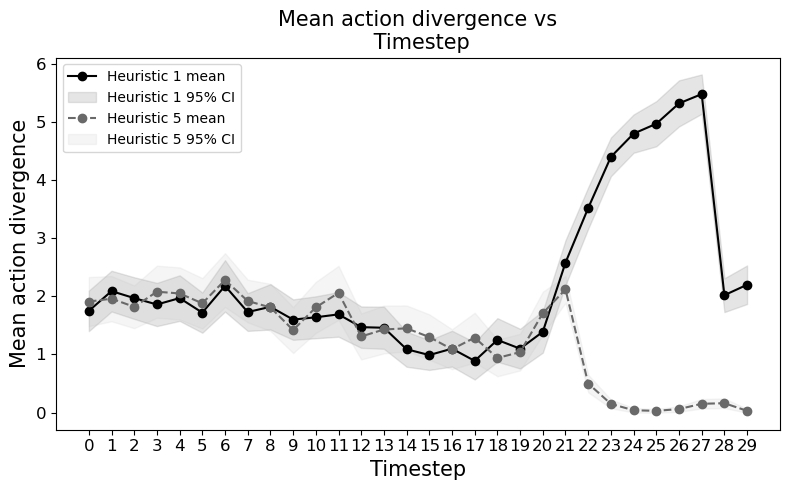

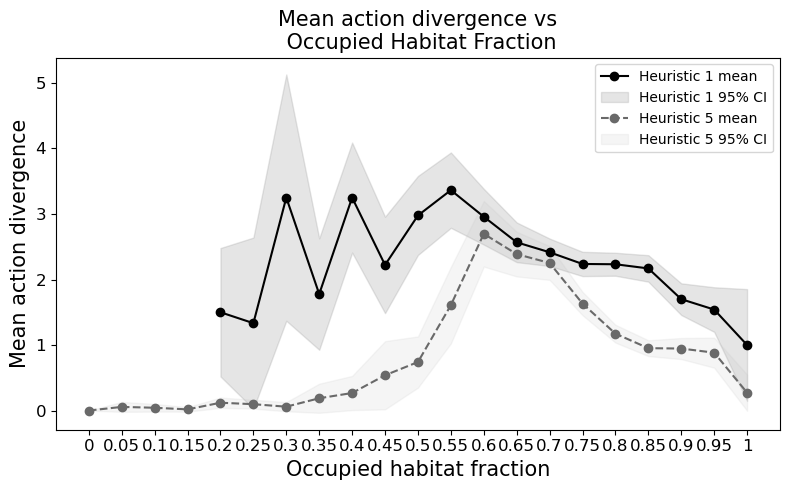

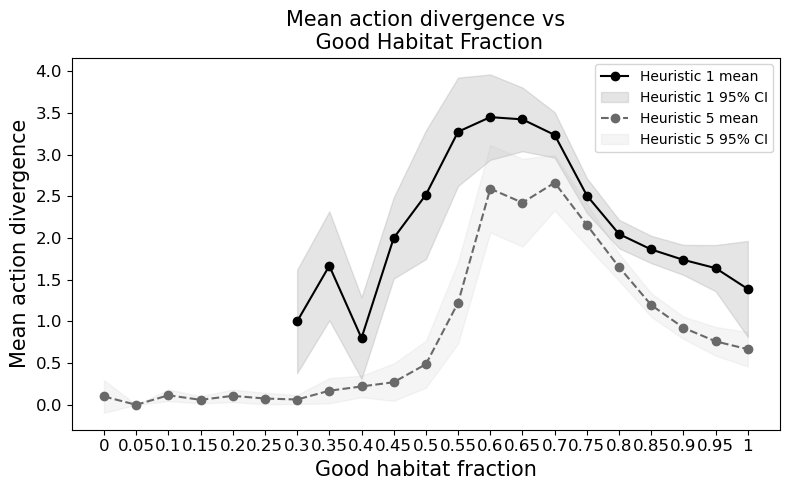

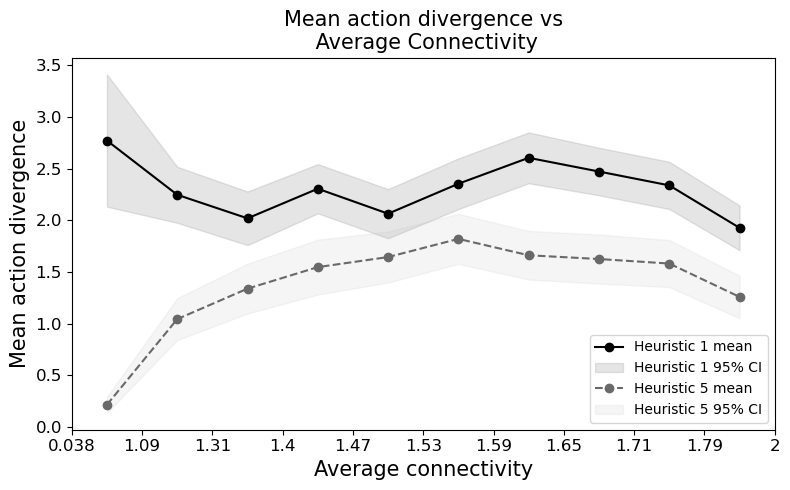

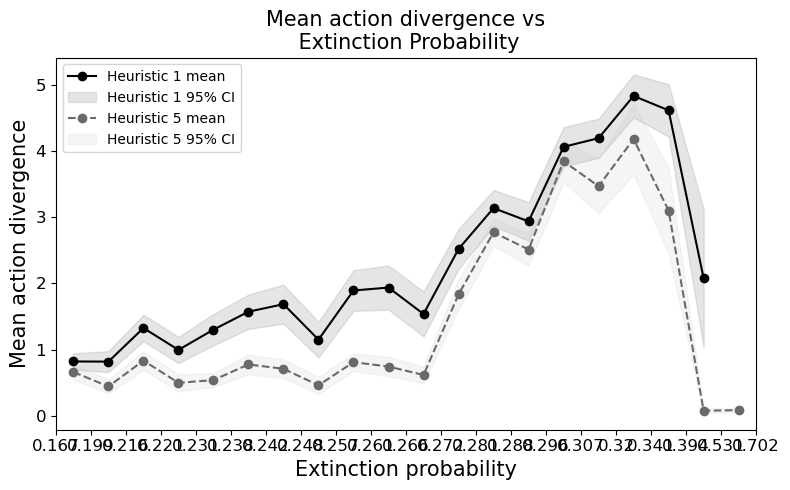

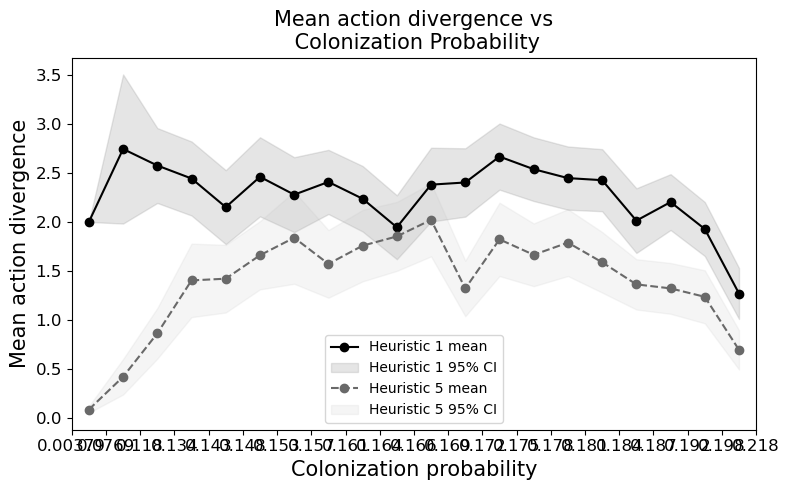

In [8]:
# for both actions (adist): heuristic 1 vs heuristic 5 vs human
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from call_in_data import call_in_data, call_in_heuristic_data

###################################################
envid = 20 # 18=n5, 20=n10 median centrality, 21=n20, 22=n10 low centrality, 23=n10 high centrality
legend_on = 1 # if 1, show legend/title; if 0, hide both.
heurtype = 4 # pre-RL observation heuristics
# only use 20. we specifically got more samples for step-scale analysis.
###################################################

# Heuristic play data (type 1 and type 5)
heur1_playdf, _ = call_in_heuristic_data(envid=envid, heuristic_type=heurtype, with_valdiff=True, merge=True)
heur5_playdf, _ = call_in_heuristic_data(envid=envid, heuristic_type=5, with_valdiff=False, merge=True)
patchnum = heur1_playdf['observations'][0].shape[0]  # assuming all observations have the same shape
print(patchnum)

# Human play data
human_playdf, _ = call_in_data(envid=envid, with_valdiff=True, merge=True)

def build_df(playdf):
    t = np.array([s[0, -1] for s in playdf['observations']])
    occfrac = playdf['occfraction_per_episode']
    goodhfrac = playdf['goodHfraction_per_episode']
    avgconn = playdf['avgconnectivity_per_episode']
    eprob = playdf['avgeprob_per_episode']
    cprob = playdf['avgcprob_per_episode']

    # Total action distance (restoration + supplementation) relative to RL action.
    adist = (np.abs(np.array(playdf['actions']) - np.array(playdf['RLactions']))).sum(axis=1)

    return pd.DataFrame({
        't': t,
        'occfrac': occfrac,
        'goodhfrac': goodhfrac,
        'avgconn': avgconn,
        'eprob': eprob,
        'cprob': cprob,
        'adist': adist,
    })

heur1_df = build_df(heur1_playdf)
heur5_df = build_df(heur5_playdf)
human_df = build_df(human_playdf)

plot_specs = [
    ('t', 20, 'Timestep', 'Mean action divergence vs\n Timestep'),
    ('occfrac', 3, 'Occupied habitat fraction', 'Mean action divergence vs\n Occupied Habitat Fraction'),
    ('goodhfrac', 3, 'Good habitat fraction', 'Mean action divergence vs\n Good Habitat Fraction'),
    ('avgconn', 10, 'Average connectivity', 'Mean action divergence vs\n Average Connectivity'),
    ('eprob', 20, 'Extinction probability', 'Mean action divergence vs\n Extinction Probability'),
    ('cprob', 20, 'Colonization probability', 'Mean action divergence vs\n Colonization Probability'),
]

discrete_cols = {'t', 'occfrac', 'goodhfrac'}

heur1_line_color = 'black'
heur1_ci_color = 'gray'
heur1_line_style = '-'
heur5_line_color = 'dimgray'
heur5_ci_color = 'silver'
heur5_line_style = '--'
human_line_color = 'black'
human_ci_color = 'gray'
human_line_style = ':'

def fill_binned_arrays(grouped_df, n_actual_bins):
    means = np.full(n_actual_bins, np.nan, dtype=float)
    stds = np.full(n_actual_bins, np.nan, dtype=float)
    counts = np.zeros(n_actual_bins, dtype=float)
    for idx, row in grouped_df.iterrows():
        if pd.notna(idx):
            i = int(idx)
            means[i] = float(row['mean'])
            stds[i] = 0.0 if pd.isna(row['std']) else float(row['std'])
            counts[i] = float(row['count'])
    return means, stds, counts

for col, n_bins, xlabel, title in plot_specs:
    h1x = pd.to_numeric(heur1_df[col], errors='coerce')
    h1y = pd.to_numeric(heur1_df['adist'], errors='coerce')
    h1v = h1x.notna() & h1y.notna()
    h1x = h1x[h1v]
    h1y = h1y[h1v]

    h5x = pd.to_numeric(heur5_df[col], errors='coerce')
    h5y = pd.to_numeric(heur5_df['adist'], errors='coerce')
    h5v = h5x.notna() & h5y.notna()
    h5x = h5x[h5v]
    h5y = h5y[h5v]

    ux = pd.to_numeric(human_df[col], errors='coerce')
    uy = pd.to_numeric(human_df['adist'], errors='coerce')
    uv = ux.notna() & uy.notna()
    ux = ux[uv]
    uy = uy[uv]

    plt.figure(figsize=(8, 5))

    if col in discrete_cols:
        all_vals = np.sort(np.unique(np.concatenate([h1x.to_numpy(), h5x.to_numpy(), ux.to_numpy()])))
        x_pos = np.arange(len(all_vals), dtype=float)

        h1_grouped = h1y.groupby(h1x).agg(['mean', 'std', 'count']).reindex(all_vals)
        h5_grouped = h5y.groupby(h5x).agg(['mean', 'std', 'count']).reindex(all_vals)
        u_grouped = uy.groupby(ux).agg(['mean', 'std', 'count']).reindex(all_vals)

        h1_means = h1_grouped['mean'].to_numpy(dtype=float)
        h1_stds = h1_grouped['std'].fillna(0.0).to_numpy(dtype=float)
        h1_counts = h1_grouped['count'].fillna(0.0).to_numpy(dtype=float)
        h1_sem = np.divide(h1_stds, np.sqrt(h1_counts), out=np.full_like(h1_stds, np.nan), where=h1_counts > 0)
        h1_ci95 = 1.96 * h1_sem

        h5_means = h5_grouped['mean'].to_numpy(dtype=float)
        h5_stds = h5_grouped['std'].fillna(0.0).to_numpy(dtype=float)
        h5_counts = h5_grouped['count'].fillna(0.0).to_numpy(dtype=float)
        h5_sem = np.divide(h5_stds, np.sqrt(h5_counts), out=np.full_like(h5_stds, np.nan), where=h5_counts > 0)
        h5_ci95 = 1.96 * h5_sem

        u_means = u_grouped['mean'].to_numpy(dtype=float)
        u_stds = u_grouped['std'].fillna(0.0).to_numpy(dtype=float)
        u_counts = u_grouped['count'].fillna(0.0).to_numpy(dtype=float)
        u_sem = np.divide(u_stds, np.sqrt(u_counts), out=np.full_like(u_stds, np.nan), where=u_counts > 0)
        u_ci95 = 1.96 * u_sem

        plt.plot(x_pos, h1_means, marker='o', linestyle=heur1_line_style, color=heur1_line_color, label='Heuristic 1 mean')
        plt.fill_between(x_pos, h1_means - h1_ci95, h1_means + h1_ci95, color=heur1_ci_color, alpha=0.20, label='Heuristic 1 95% CI')
        plt.plot(x_pos, h5_means, marker='o', linestyle=heur5_line_style, color=heur5_line_color, label='Heuristic 5 mean')
        plt.fill_between(x_pos, h5_means - h5_ci95, h5_means + h5_ci95, color=heur5_ci_color, alpha=0.15, label='Heuristic 5 95% CI')
        #plt.plot(x_pos, u_means, marker='o', linestyle=human_line_style, color=human_line_color, label='Human mean')
        #plt.fill_between(x_pos, u_means - u_ci95, u_means + u_ci95, color=human_ci_color, alpha=0.10, label='Human 95% CI')

        plt.xticks(x_pos, [f'{v:g}' for v in all_vals], fontsize=12)
        plt.xlabel(xlabel, fontsize=15)
        plt.yticks(fontsize=12)
    else:
        all_x = pd.concat([h1x, h5x, ux], ignore_index=True)
        _, bin_edges = pd.qcut(all_x, q=n_bins, retbins=True, duplicates='drop')
        n_actual_bins = len(bin_edges) - 1

        h1_ids = pd.cut(h1x, bins=bin_edges, include_lowest=True, labels=False)
        h5_ids = pd.cut(h5x, bins=bin_edges, include_lowest=True, labels=False)
        u_ids = pd.cut(ux, bins=bin_edges, include_lowest=True, labels=False)

        h1_grouped = h1y.groupby(h1_ids).agg(['mean', 'std', 'count'])
        h5_grouped = h5y.groupby(h5_ids).agg(['mean', 'std', 'count'])
        u_grouped = uy.groupby(u_ids).agg(['mean', 'std', 'count'])

        h1_means, h1_stds, h1_counts = fill_binned_arrays(h1_grouped, n_actual_bins)
        h5_means, h5_stds, h5_counts = fill_binned_arrays(h5_grouped, n_actual_bins)
        u_means, u_stds, u_counts = fill_binned_arrays(u_grouped, n_actual_bins)

        h1_sem = np.divide(h1_stds, np.sqrt(h1_counts), out=np.full_like(h1_stds, np.nan), where=h1_counts > 0)
        h1_ci95 = 1.96 * h1_sem
        h5_sem = np.divide(h5_stds, np.sqrt(h5_counts), out=np.full_like(h5_stds, np.nan), where=h5_counts > 0)
        h5_ci95 = 1.96 * h5_sem
        u_sem = np.divide(u_stds, np.sqrt(u_counts), out=np.full_like(u_stds, np.nan), where=u_counts > 0)
        u_ci95 = 1.96 * u_sem

        x_mean_pos = np.arange(n_actual_bins, dtype=float) + 0.5
        x_edge_pos = np.arange(n_actual_bins + 1, dtype=float)
        edge_labels = [f'{e:.3g}' for e in bin_edges]

        plt.plot(x_mean_pos, h1_means, marker='o', linestyle=heur1_line_style, color=heur1_line_color, label='Heuristic 1 mean')
        plt.fill_between(x_mean_pos, h1_means - h1_ci95, h1_means + h1_ci95, color=heur1_ci_color, alpha=0.20, label='Heuristic 1 95% CI')
        plt.plot(x_mean_pos, h5_means, marker='o', linestyle=heur5_line_style, color=heur5_line_color, label='Heuristic 5 mean')
        plt.fill_between(x_mean_pos, h5_means - h5_ci95, h5_means + h5_ci95, color=heur5_ci_color, alpha=0.15, label='Heuristic 5 95% CI')
        #plt.plot(x_mean_pos, u_means, marker='o', linestyle=human_line_style, color=human_line_color, label='Human mean')
        #plt.fill_between(x_mean_pos, u_means - u_ci95, u_means + u_ci95, color=human_ci_color, alpha=0.10, label='Human 95% CI')

        plt.xticks(x_edge_pos, edge_labels, fontsize=12)
        plt.yticks(fontsize=12)
        plt.xlim(0, n_actual_bins)
        plt.xlabel(xlabel, fontsize=15)

    plt.ylabel('Mean action divergence', fontsize=15)
    if legend_on == 1:
        plt.title(title, fontsize=15)
        plt.legend()
    plt.tight_layout()
    plt.show()

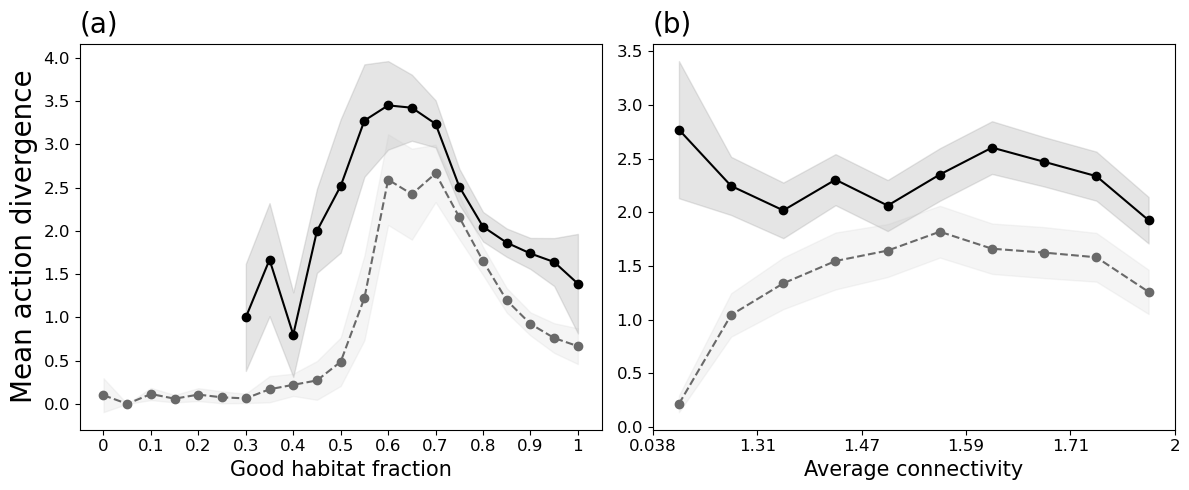

In [12]:
# 1x2 subplot for both actions (adist): heuristic 1 vs heuristic 5 vs human
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from call_in_data import call_in_data, call_in_heuristic_data

envid = 21
legend_on = 0
heurtype = 4 # pre-RL observation heuristics
heur1_playdf, _ = call_in_heuristic_data(envid=envid, heuristic_type=heurtype, with_valdiff=True, merge=True)
heur5_playdf, _ = call_in_heuristic_data(envid=envid, heuristic_type=5, with_valdiff=False, merge=True)
human_playdf, _ = call_in_data(envid=envid, with_valdiff=True, merge=True)

def build_df_both(playdf):
    return pd.DataFrame({
        'goodhfrac': pd.to_numeric(playdf['goodHfraction_per_episode'], errors='coerce'),
        'avgconn': pd.to_numeric(playdf['avgconnectivity_per_episode'], errors='coerce'),
        'adist': (np.abs(np.array(playdf['actions']) - np.array(playdf['RLactions']))).sum(axis=1),
    })

heur1_df = build_df_both(heur1_playdf)
heur5_df = build_df_both(heur5_playdf)
human_df = build_df_both(human_playdf)

plot_specs = [
    ('goodhfrac', 3, 'Good habitat fraction', 'Mean action divergence vs\n Good Habitat Fraction'),
    ('avgconn', 10, 'Average connectivity', 'Mean action divergence vs\n Average Connectivity'),
]

discrete_cols = {'goodhfrac'}

heur1_line_color = 'black'
heur1_ci_color = 'gray'
heur1_line_style = '-'
heur5_line_color = 'dimgray'
heur5_ci_color = 'silver'
heur5_line_style = '--'
human_line_color = 'black'
human_ci_color = 'gray'
human_line_style = ':'

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
letters = 'abcdefghijklmnopqrstuvwxyz'

for i, (ax, (col, n_bins, xlabel, title)) in enumerate(zip(axs, plot_specs)):
    h1x = pd.to_numeric(heur1_df[col], errors='coerce')
    h1y = pd.to_numeric(heur1_df['adist'], errors='coerce')
    h1v = h1x.notna() & h1y.notna()
    h1x = h1x[h1v]
    h1y = h1y[h1v]

    h5x = pd.to_numeric(heur5_df[col], errors='coerce')
    h5y = pd.to_numeric(heur5_df['adist'], errors='coerce')
    h5v = h5x.notna() & h5y.notna()
    h5x = h5x[h5v]
    h5y = h5y[h5v]

    ux = pd.to_numeric(human_df[col], errors='coerce')
    uy = pd.to_numeric(human_df['adist'], errors='coerce')
    uv = ux.notna() & uy.notna()
    ux = ux[uv]
    uy = uy[uv]

    if col in discrete_cols:
        all_vals = np.sort(np.unique(np.concatenate([h1x.to_numpy(), h5x.to_numpy(), ux.to_numpy()])))
        x_pos = np.arange(len(all_vals), dtype=float)

        h1_grouped = h1y.groupby(h1x).agg(['mean', 'std', 'count']).reindex(all_vals)
        h5_grouped = h5y.groupby(h5x).agg(['mean', 'std', 'count']).reindex(all_vals)
        u_grouped = uy.groupby(ux).agg(['mean', 'std', 'count']).reindex(all_vals)

        h1_means = h1_grouped['mean'].to_numpy(dtype=float)
        h1_stds = h1_grouped['std'].fillna(0.0).to_numpy(dtype=float)
        h1_counts = h1_grouped['count'].fillna(0.0).to_numpy(dtype=float)
        h1_sem = np.divide(h1_stds, np.sqrt(h1_counts), out=np.full_like(h1_stds, np.nan), where=h1_counts > 0)
        h1_ci95 = 1.96 * h1_sem

        h5_means = h5_grouped['mean'].to_numpy(dtype=float)
        h5_stds = h5_grouped['std'].fillna(0.0).to_numpy(dtype=float)
        h5_counts = h5_grouped['count'].fillna(0.0).to_numpy(dtype=float)
        h5_sem = np.divide(h5_stds, np.sqrt(h5_counts), out=np.full_like(h5_stds, np.nan), where=h5_counts > 0)
        h5_ci95 = 1.96 * h5_sem

        u_means = u_grouped['mean'].to_numpy(dtype=float)
        u_stds = u_grouped['std'].fillna(0.0).to_numpy(dtype=float)
        u_counts = u_grouped['count'].fillna(0.0).to_numpy(dtype=float)
        u_sem = np.divide(u_stds, np.sqrt(u_counts), out=np.full_like(u_stds, np.nan), where=u_counts > 0)
        u_ci95 = 1.96 * u_sem

        ax.plot(x_pos, h1_means, marker='o', linestyle=heur1_line_style, color=heur1_line_color, label='Heuristic 1 mean')
        ax.fill_between(x_pos, h1_means - h1_ci95, h1_means + h1_ci95, color=heur1_ci_color, alpha=0.20, label='Heuristic 1 95% CI')
        ax.plot(x_pos, h5_means, marker='o', linestyle=heur5_line_style, color=heur5_line_color, label='Heuristic 5 mean')
        ax.fill_between(x_pos, h5_means - h5_ci95, h5_means + h5_ci95, color=heur5_ci_color, alpha=0.15, label='Heuristic 5 95% CI')
        #ax.plot(x_pos, u_means, marker='o', linestyle=human_line_style, color=human_line_color, label='Human mean')
        #ax.fill_between(x_pos, u_means - u_ci95, u_means + u_ci95, color=human_ci_color, alpha=0.10, label='Human 95% CI')

        tick_idx = np.arange(0, len(x_pos), 2)
        ax.set_xticks(x_pos[tick_idx], [f'{v:g}' for v in all_vals[tick_idx]], fontsize=12)
        ax.tick_params(axis='y', labelsize=12)
        ax.set_xlabel(xlabel, fontsize=15)
    else:
        all_x = pd.concat([h1x, h5x, ux], ignore_index=True)
        _, bin_edges = pd.qcut(all_x, q=n_bins, retbins=True, duplicates='drop')
        n_actual_bins = len(bin_edges) - 1

        h1_ids = pd.cut(h1x, bins=bin_edges, include_lowest=True, labels=False)
        h5_ids = pd.cut(h5x, bins=bin_edges, include_lowest=True, labels=False)
        u_ids = pd.cut(ux, bins=bin_edges, include_lowest=True, labels=False)

        h1_grouped = h1y.groupby(h1_ids).agg(['mean', 'std', 'count'])
        h5_grouped = h5y.groupby(h5_ids).agg(['mean', 'std', 'count'])
        u_grouped = uy.groupby(u_ids).agg(['mean', 'std', 'count'])

        h1_means = np.full(n_actual_bins, np.nan, dtype=float)
        h1_stds = np.full(n_actual_bins, np.nan, dtype=float)
        h1_counts = np.zeros(n_actual_bins, dtype=float)
        for idx, row in h1_grouped.iterrows():
            if pd.notna(idx):
                i_bin = int(idx)
                h1_means[i_bin] = float(row['mean'])
                h1_stds[i_bin] = 0.0 if pd.isna(row['std']) else float(row['std'])
                h1_counts[i_bin] = float(row['count'])

        h5_means = np.full(n_actual_bins, np.nan, dtype=float)
        h5_stds = np.full(n_actual_bins, np.nan, dtype=float)
        h5_counts = np.zeros(n_actual_bins, dtype=float)
        for idx, row in h5_grouped.iterrows():
            if pd.notna(idx):
                i_bin = int(idx)
                h5_means[i_bin] = float(row['mean'])
                h5_stds[i_bin] = 0.0 if pd.isna(row['std']) else float(row['std'])
                h5_counts[i_bin] = float(row['count'])

        u_means = np.full(n_actual_bins, np.nan, dtype=float)
        u_stds = np.full(n_actual_bins, np.nan, dtype=float)
        u_counts = np.zeros(n_actual_bins, dtype=float)
        for idx, row in u_grouped.iterrows():
            if pd.notna(idx):
                i_bin = int(idx)
                u_means[i_bin] = float(row['mean'])
                u_stds[i_bin] = 0.0 if pd.isna(row['std']) else float(row['std'])
                u_counts[i_bin] = float(row['count'])

        h1_sem = np.divide(h1_stds, np.sqrt(h1_counts), out=np.full_like(h1_stds, np.nan), where=h1_counts > 0)
        h5_sem = np.divide(h5_stds, np.sqrt(h5_counts), out=np.full_like(h5_stds, np.nan), where=h5_counts > 0)
        u_sem = np.divide(u_stds, np.sqrt(u_counts), out=np.full_like(u_stds, np.nan), where=u_counts > 0)
        h1_ci95 = 1.96 * h1_sem
        h5_ci95 = 1.96 * h5_sem
        u_ci95 = 1.96 * u_sem

        x_mean_pos = np.arange(n_actual_bins, dtype=float) + 0.5
        x_edge_pos = np.arange(n_actual_bins + 1, dtype=float)
        edge_labels = [f'{e:.3g}' for e in bin_edges]

        ax.plot(x_mean_pos, h1_means, marker='o', linestyle=heur1_line_style, color=heur1_line_color, label='Heuristic 1 mean')
        ax.fill_between(x_mean_pos, h1_means - h1_ci95, h1_means + h1_ci95, color=heur1_ci_color, alpha=0.20, label='Heuristic 1 95% CI')
        ax.plot(x_mean_pos, h5_means, marker='o', linestyle=heur5_line_style, color=heur5_line_color, label='Heuristic 5 mean')
        ax.fill_between(x_mean_pos, h5_means - h5_ci95, h5_means + h5_ci95, color=heur5_ci_color, alpha=0.15, label='Heuristic 5 95% CI')
        #ax.plot(x_mean_pos, u_means, marker='o', linestyle=human_line_style, color=human_line_color, label='Human mean')
        #ax.fill_between(x_mean_pos, u_means - u_ci95, u_means + u_ci95, color=human_ci_color, alpha=0.10, label='Human 95% CI')

        tick_idx = np.arange(0, len(x_edge_pos), 2)
        ax.set_xticks(x_edge_pos[tick_idx], [edge_labels[k] for k in tick_idx], fontsize=12)
        ax.tick_params(axis='y', labelsize=12)
        ax.set_xlim(0, n_actual_bins)
        ax.set_xlabel(xlabel, fontsize=15)

    ax.text(0.0, 1.03, f'({letters[i]})', transform=ax.transAxes, fontsize=20)
    if legend_on == 1:
        ax.set_title(title, fontsize=15)

axs[0].set_ylabel('Mean action divergence', fontsize=20)
if legend_on == 1:
    axs[0].legend()

plt.tight_layout()
plt.show()

# Figure 3. bar plot

In [3]:
from call_in_data import *
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr
###################################################
envid = 20 # 18= n5, 20=n10 median centrality, 21=n20, 22=n10 low centrality, 23=n10 high centrality
use_connectivity_weighted_action = 0 # 0=no, 1=connectivity weighted, 2=inv connectivity weighted
heur = 1 # if 1, use heuristic data; if 0, use human data.
###################################################
R2onlystate = []
R2onlyaction = []
R2full = []
rresidcorrs = []
rresidcorrs_significant = []
sresidcorrs = []
sresidcorrs_significant = []

for envid in [18,20,21,22,23]:
    if heur == 1:
        playdf,_ = call_in_heuristic_data(envid=envid, with_valdiff=True, merge=True)
    else:
        playdf, _ = call_in_data(envid=envid, with_valdiff=True, merge=True)
    patchnum = playdf['observations'][0].shape[0]  # assuming all observations have the same shape
    delV, V_human, V_pi = zip(*playdf['performance_gap'])
    t = np.array([s[0,-1] for s in playdf['observations']])
    connectivity = np.array([s[:,2] for s in playdf['observations']])
    invconnectivity = 1/(connectivity+1e-5)  # add small constant to avoid division by zero
    occfrac = playdf['occfraction_per_episode']
    adist = playdf['L1_a_dist_RLsampled_a']
    connectivity_expanded = np.concatenate([connectivity, connectivity], axis=1)
    invconnectivity_expanded = np.concatenate([invconnectivity, invconnectivity], axis=1)
    connecadist = (np.abs(np.array(playdf['actions']) - np.array(playdf['RLactions']))*connectivity_expanded).sum(axis=1)  # connectivity weighted L1 distance
    invconnecadist = (np.abs(np.array(playdf['actions']) - np.array(playdf['RLactions']))*invconnectivity_expanded).sum(axis=1)  # inverse connectivity weighted L1 distance
    radist = (np.abs(np.array(playdf['actions']) - np.array(playdf['RLactions']))[:,:patchnum]).sum(axis=1)
    sadist = (np.abs(np.array(playdf['actions']) - np.array(playdf['RLactions']))[:,patchnum:]).sum(axis=1)
    connecradist = (np.abs(np.array(playdf['actions']) - np.array(playdf['RLactions']))[:,:patchnum]*connectivity).sum(axis=1)
    invconnecradist = (np.abs(np.array(playdf['actions']) - np.array(playdf['RLactions']))[:,:patchnum]*invconnectivity).sum(axis=1)
    connecsadist = (np.abs(np.array(playdf['actions']) - np.array(playdf['RLactions']))[:,patchnum:]*connectivity).sum(axis=1)
    invconnecsadist = (np.abs(np.array(playdf['actions']) - np.array(playdf['RLactions']))[:,patchnum:]*invconnectivity).sum(axis=1)
    goodhfrac = playdf['goodHfraction_per_episode']
    avgconn = playdf['avgconnectivity_per_episode']
    eprob = playdf['avgeprob_per_episode']
    cprob = playdf['avgcprob_per_episode']
    restorefrac = playdf['restore_fraction_per_episode']
    suppfrac = playdf['supp_fraction_per_episode']

    import statsmodels.api as sm
    import pandas as pd
    from sklearn.preprocessing import StandardScaler

    df = pd.DataFrame({
        'delV': delV,
        't': t,
        'occfrac': occfrac,
        'goodhfrac': goodhfrac,
        'avgconn': avgconn,
        'eprob': eprob,
        'cprob': cprob,
        'radist': radist,
        'sadist': sadist,
        'connecradist': connecradist,
        'invconnecradist': invconnecradist,
        'connecsadist': connecsadist,
        'invconnecsadist': invconnecsadist,
    })


    # 
    # standardize
    cols = ['t','occfrac','goodhfrac','avgconn','eprob','radist','sadist']
    state_cols = ['t','occfrac','goodhfrac','avgconn','eprob']
    if use_connectivity_weighted_action == 0:
        adist_cols = ['radist','sadist']
    elif use_connectivity_weighted_action == 1:
        adist_cols = ['connecradist','connecsadist']
    elif use_connectivity_weighted_action == 2:
        adist_cols = ['invconnecradist','invconnecsadist']
    df_std = df.copy()
    df_std[cols] = StandardScaler().fit_transform(df[cols])
    # Model A: state only
    Xa = sm.add_constant(df_std[state_cols])
    modelA = sm.OLS(df_std['delV'], Xa).fit()
    R2onlystate.append(modelA.rsquared)
    # Model B: action distance only
    Xb = sm.add_constant(df_std[adist_cols])
    modelB = sm.OLS(df_std['delV'], Xb).fit()
    R2onlyaction.append(modelB.rsquared)
    # Model C: full model
    Xc = sm.add_constant(df_std[state_cols + adist_cols])
    modelC = sm.OLS(df_std['delV'], Xc).fit()
    R2full.append(modelC.rsquared)

    # check partial effect of action distance by looking at residuals
    resid_y = modelA.resid
    Xa_dist = sm.add_constant(df_std[state_cols])
    model_dist = sm.OLS(df_std[adist_cols[0]], Xa_dist).fit()
    model_dist2 = sm.OLS(df_std[adist_cols[1]], Xa_dist).fit()
    resid_x = model_dist.resid
    resid_x2 = model_dist2.resid

    residcor, resid_p = pearsonr(resid_x, resid_y)
    residcor2, resid_p2 = pearsonr(resid_x2, resid_y)
    rresidcorrs.append(residcor)
    sresidcorrs.append(residcor2)
    rresidcorrs_significant.append(resid_p < 0.05)
    sresidcorrs_significant.append(resid_p2 < 0.05)

for i, envid in enumerate([18,20,21,22,23]):
    print(f'supplementation partial effect residual correlations for env {envid}: {sresidcorrs[i]:.4f}, significant: {sresidcorrs_significant[i]}')
    print(f'restoration partial effect residual correlations for env {envid}: {rresidcorrs[i]:.4f}, significant: {rresidcorrs_significant[i]}')
    print(f'\n')

# grouped barplot, group=envi, within group: R2full, R2onlystate, R2onlyaction (in that order), no colors, only grey scale. use group name for group xlabel
group_name = {
    18: 'N=5',
    20: 'N=10',
    21: 'N=20',
    22: 'N=10 \nlow centrality',
    23: 'N=10 \nhigh centrality',
}

env_order = [18, 20, 21, 22, 23]
labels = [group_name[e] for e in env_order]
x = np.arange(len(env_order), dtype=float)
width = 0.24

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, R2full, width, color='0.25', label='state + action div.')
ax.bar(x, R2onlystate, width, color='0.55', label='state only')
ax.bar(x + width, R2onlyaction, width, color='0.80', label='action div. only')

ax.set_xticks(x, labels, fontsize=16)
ax.set_ylabel(r'$R^2$', fontsize=15)
ax.set_ylim(0, max(max(R2full), max(R2onlystate), max(R2onlyaction)) * 1.20)
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=12)
# xlabel size larger 
ax.legend(frameon=False, fontsize=15)

plt.tight_layout()
plt.show()

IndexError: list index out of range

In [93]:
np.round(np.array(R2onlyaction)/np.array(R2onlystate), 2)


array([0.15, 0.25, 0.91, 0.62, 0.42])

n=18, t-statistic=-2.17, p-value=0.0301


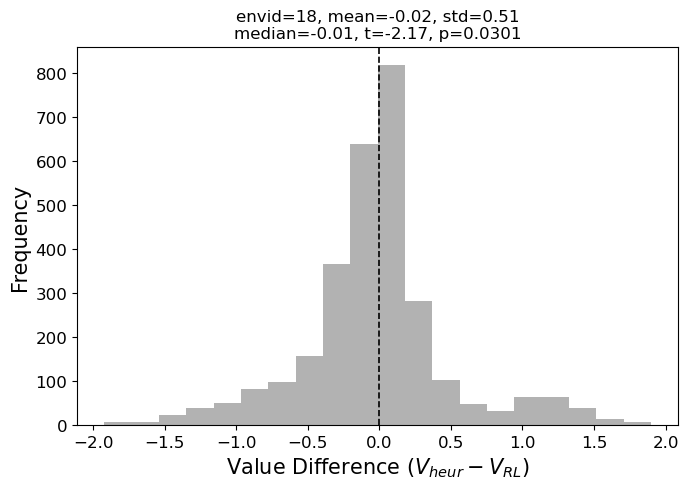

n=20, t-statistic=-19.83, p-value=0.0000


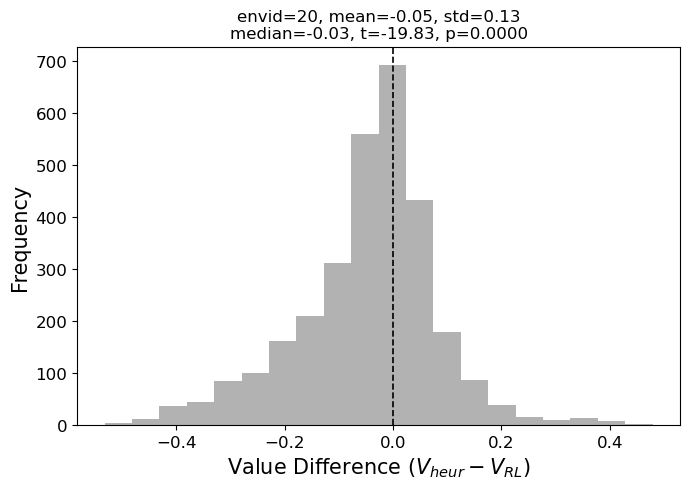

n=21, t-statistic=-23.59, p-value=0.0000


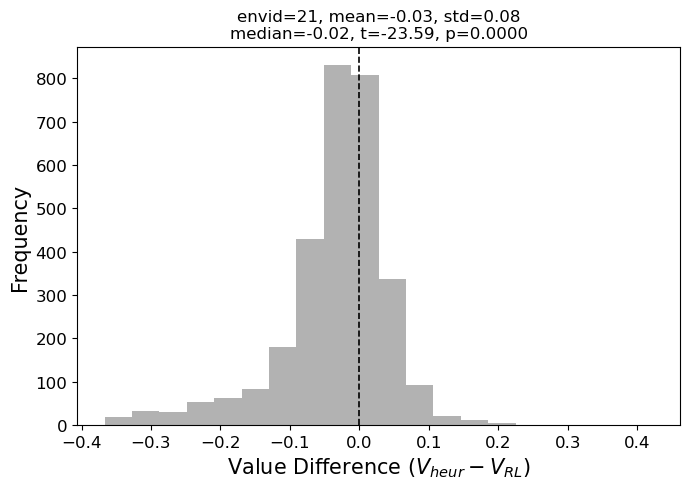

n=22, t-statistic=-19.20, p-value=0.0000


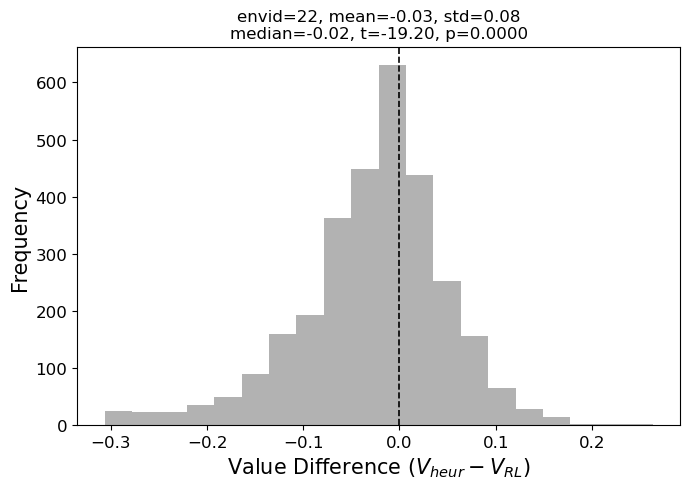

n=23, t-statistic=-17.95, p-value=0.0000


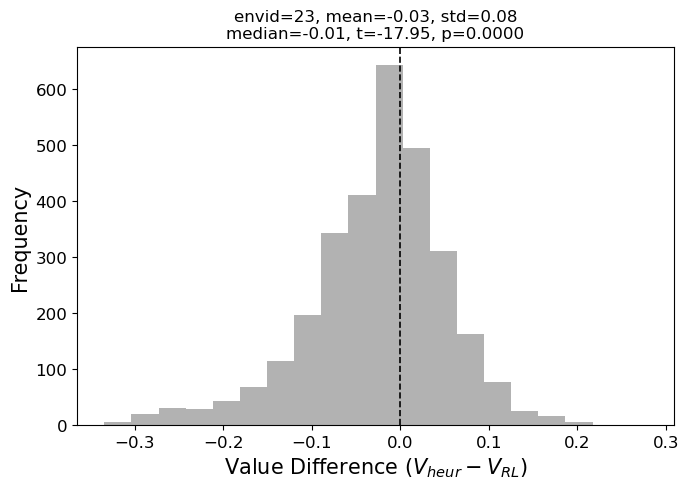

In [88]:
# histogram of value differences
from call_in_data import *
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
notitle = False
envids = [18, 20, 21, 22, 23]

for n in envids:
    playdf, filenames = call_in_heuristic_data(envid=n, with_valdiff=True, merge=True)
    delV, V_human, V_pi = zip(*playdf['performance_gap'])
    t_stat, p_value = stats.ttest_1samp(delV, 0)
    print(f'n={n}, t-statistic={t_stat:.2f}, p-value={p_value:.4f}')

    plt.figure(figsize=(7, 5))
    plt.hist(delV, bins=20, color='grey', alpha=0.60)
    plt.axvline(0, color='black', linestyle='--', linewidth=1.2)
    if not notitle:
        plt.title(f'envid={n}, mean={np.mean(delV):.2f}, std={np.std(delV):.2f}\nmedian={np.median(delV):.2f}, t={t_stat:.2f}, p={p_value:.4f}')
    plt.xlabel(r'Value Difference ($V_{heur} - V_{RL}$)', fontsize=15)
    plt.ylabel('Frequency', fontsize=15)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    plt.show()